<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº4 Primeras nociones de estimacion espectral
#### Lucas Ignacio Rodriguez




##  Introducción y Objetivos
El objetivo de este trabajo es analizar y comparar el desempeño de distintos estimadores espectrales de **amplitud** ($\hat{a}_1$) y **frecuencia** ($\hat{f}_1$) para una señal senoidal inmersa en ruido blanco aditivo Gaussiano (AWGN). 

Mediante simulaciones de Monte Carlo ($M = 200$ realizaciones), se evalúa cómo la fuga espectral (*spectral leakage*) y el efecto de desintonía (*scalloping loss*) afectan a la estimación puntual según la ventana de ponderación seleccionada y la relación señal a ruido ($\text{SNR}$).

##  Modelo de la Señal
La señal discreta analizada se define como:

$$x[n] = a_0 \cdot \sin(2\pi f_1 t) + n_a[n]$$

Donde:
* **Frecuencia de muestreo:** $f_s = 1000 \text{ Hz}$, con $N = 1000 \text{ muestras}$.
* **Frecuencia central:** $f_0 = 250 \text{ Hz}$ ($\text{bin } N/4$).
* **Desintonía aleatoria:** $f_1 = f_0 + f_r \cdot \frac{f_s}{N}$, con $f_r \sim \mathcal{U}(-2, 2) \text{ Hz}$.
* **Potencia de la senoidal:** Calibrada a $P_x = 1 \text{ W} \implies a_0 = \sqrt{2}$.
* **Ruido aditivo:** $n_a[n] \sim \mathcal{N}(0, \sigma^2)$, parametrizado para $\text{SNR} \in \{3\text{ dB}, 10\text{ dB}\}$.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as sp

# -----------------------------------------------------------------------------
# Configuración General de la Simulación (en Hz)
# -----------------------------------------------------------------------------
fs = 1000          # Frecuencia de muestreo [Hz]
N = 1000           # Muestras por realización
M = 200            # Cantidad de realizaciones Monte Carlo
a0 = np.sqrt(2)    # Calibración para Potencia = (a0^2)/2 = 1 W
f0 = fs / 4        # Frecuencia central f0 = 250 Hz (Bin N/4 = 250)
bin_250 = 250

tt = np.arange(0, N).reshape(N, 1) / fs # Vector de tiempo en segundos

# Fijamos semilla para repetibilidad
np.random.seed(42)

# Desintonía aleatoria fr ~ U(-2, 2) Hz
fr = np.random.uniform(-2, 2, M)
f1_real = f0 + fr * (fs / N) # f1 en Hz

# Matriz de senoidal pura en Hz (N muestras x M realizaciones)
xx_puro = a0 * np.sin(2 * np.pi * f1_real * tt)

# Diccionario global para acumular los resultados
resultados = {
    3:  {v: {'a1': None, 'f1': None} for v in ['Rectangular', 'Flattop', 'Blackman-Harris', 'Hann']},
    10: {v: {'a1': None, 'f1': None} for v in ['Rectangular', 'Flattop', 'Blackman-Harris', 'Hann']}
}

In [5]:
# -----------------------------------------------------------------------------
# Experimento: Sin Ventana (Rectangular) | SNR = 3 dB (en Hz)
# -----------------------------------------------------------------------------
snr = 3
sigma = np.sqrt(10**(-snr / 10))
n_a = np.random.normal(0, sigma, (N, M))
xx_3db = xx_puro + n_a

# FFT directa (Sin ventanear)
X_rect = np.fft.rfft(xx_3db, axis=0)
mag_X_rect = (2 / N) * np.abs(X_rect)

# Estimador de Amplitud evaluado en el Bin 250 (250 Hz)
a1_est_rect_3db = mag_X_rect[bin_250, :]

# Estimador de Frecuencia en Hz: Bin del pico * (fs / N)
k_max_rect = np.argmax(mag_X_rect, axis=0)
f1_est_rect_3db = k_max_rect * (fs / N) # [Hz]

# Guardar en la estructura global
resultados[3]['Rectangular']['a1'] = a1_est_rect_3db
resultados[3]['Rectangular']['f1'] = f1_est_rect_3db

# Sesgo y Varianza
sesgo_a = np.mean(a1_est_rect_3db) - a0
var_a = np.var(a1_est_rect_3db)

sesgo_f = np.mean(f1_est_rect_3db) - f0
var_f = np.var(f1_est_rect_3db)

print(f"--- Sin Ventana (SNR = 3 dB) ---")
print(f"Amplitud (250 Hz)  -> Sesgo: {sesgo_a:.6f} | Varianza: {var_a:.6f}")
print(f"Frecuencia (en Hz) -> Sesgo: {sesgo_f:.6f} Hz | Varianza: {var_f:.6f} Hz²")

--- Sin Ventana (SNR = 3 dB) ---
Amplitud (250 Hz)  -> Sesgo: -0.933639 | Varianza: 0.189545
Frecuencia (en Hz) -> Sesgo: -0.080000 Hz | Varianza: 1.633600 Hz²


In [7]:
# -----------------------------------------------------------------------------
# Experimento: Ventana Flattop | SNR = 3 dB
# -----------------------------------------------------------------------------
win_flattop = sp.flattop(N).reshape(N, 1)

# Aplicamos la ventana a la matriz de señales xx_3db (ya generada en la Celda 2)
xx_flattop = xx_3db * win_flattop

# FFT y corrección de escala por la ganancia de la ventana (Parseval)
X_flattop = np.fft.rfft(xx_flattop, axis=0)
scale_flattop = np.sum(win_flattop)
mag_X_flattop = (2 / scale_flattop) * np.abs(X_flattop)

# Estimador de Amplitud: pico máximo en el espectro enventanado
k_max_flat = np.argmax(mag_X_flattop, axis=0)
a1_est_flat_3db = mag_X_flat_val = mag_X_flattop[k_max_flat, np.arange(M)]

# Estimador de Frecuencia en Hz
f1_est_flat_3db = k_max_flat * (fs / N)

# Guardar en la estructura global
resultados[3]['Flattop']['a1'] = a1_est_flat_3db
resultados[3]['Flattop']['f1'] = f1_est_flat_3db

# Sesgo y Varianza
sesgo_a_flat = np.mean(a1_est_flat_3db) - a0
var_a_flat = np.var(a1_est_flat_3db)

sesgo_f_flat = np.mean(f1_est_flat_3db) - f0
var_f_flat = np.var(f1_est_flat_3db)

print(f"--- Ventana Flattop --- (SNR = 3 dB)")
print(f"Amplitud  -> Sesgo: {sesgo_a_flat:.6f} | Varianza: {var_a_flat:.6f}")
print(f"Frecuencia (en Hz) -> Sesgo: {sesgo_f_flat:.6f} Hz | Varianza: {var_f_flat:.6f} Hz²")

--- Ventana Flattop --- (SNR = 3 dB)
Amplitud  -> Sesgo: 0.006560 | Varianza: 0.004172
Frecuencia (en Hz) -> Sesgo: -0.130000 Hz | Varianza: 1.473100 Hz²


In [4]:
# -----------------------------------------------------------------------------
# Experimento: Ventana Blackman-Harris | SNR = 3 dB
# -----------------------------------------------------------------------------
win_bmh = sp.blackmanharris(N).reshape(N, 1)

# Aplicamos la ventana a xx_3db
xx_bmh = xx_3db * win_bmh

# FFT y corrección de escala por la ganancia de la ventana (Parseval)
X_bmh = np.fft.rfft(xx_bmh, axis=0)
scale_bmh = np.sum(win_bmh)
mag_X_bmh = (2 / scale_bmh) * np.abs(X_bmh)

# Estimador de Amplitud: pico máximo en el espectro enventanado
k_max_bmh = np.argmax(mag_X_bmh, axis=0)
a1_est_bmh_3db = mag_X_bmh[k_max_bmh, np.arange(M)]

# Estimador de Frecuencia en Hz
f1_est_bmh_3db = k_max_bmh * (fs / N)

# Guardar en la estructura global
resultados[3]['Blackman-Harris']['a1'] = a1_est_bmh_3db
resultados[3]['Blackman-Harris']['f1'] = f1_est_bmh_3db

# Sesgo y Varianza
sesgo_a_bmh = np.mean(a1_est_bmh_3db) - a0
var_a_bmh = np.var(a1_est_bmh_3db)

sesgo_f_bmh = np.mean(f1_est_bmh_3db) - f0
var_f_bmh = np.var(f1_est_bmh_3db)

print(f"--- Ventana Blackman-Harris (SNR = 3 dB) ---")
print(f"Amplitud  -> Sesgo: {sesgo_a_bmh:.6f} | Varianza: {var_a_bmh:.6f}")
print(f"Frecuencia (en Hz) -> Sesgo: {sesgo_f_bmh:.6f} Hz | Varianza: {var_f_bmh:.6f} Hz²")

--- Ventana Blackman-Harris (SNR = 3 dB) ---
Amplitud  -> Sesgo: -0.041036 | Varianza: 0.003809
Frecuencia (en Hz) -> Sesgo: -0.065000 Hz | Varianza: 1.580775 Hz²


In [5]:
# -----------------------------------------------------------------------------
# Experimento: Ventana Hann | SNR = 3 dB
# -----------------------------------------------------------------------------
win_hann = sp.hann(N).reshape(N, 1)

# Aplicamos la ventana a xx_3db
xx_hann = xx_3db * win_hann

# FFT y corrección de escala por la ganancia de la ventana (Parseval)
X_hann = np.fft.rfft(xx_hann, axis=0)
scale_hann = np.sum(win_hann)
mag_X_hann = (2 / scale_hann) * np.abs(X_hann)

# Estimador de Amplitud: pico máximo en el espectro enventanado
k_max_hann = np.argmax(mag_X_hann, axis=0)
a1_est_hann_3db = mag_X_hann[k_max_hann, np.arange(M)]

# Estimador de Frecuencia en Hz
f1_est_hann_3db = k_max_hann * (fs / N)

# Guardar en la estructura global
resultados[3]['Hann']['a1'] = a1_est_hann_3db
resultados[3]['Hann']['f1'] = f1_est_hann_3db

# Sesgo y Varianza
sesgo_a_hann = np.mean(a1_est_hann_3db) - a0
var_a_hann = np.var(a1_est_hann_3db)

sesgo_f_hann = np.mean(f1_est_hann_3db) - f0
var_f_hann = np.var(f1_est_hann_3db)

print(f"--- Ventana Hann (SNR = 3 dB) ---")
print(f"Amplitud  -> Sesgo: {sesgo_a_hann:.6f} | Varianza: {var_a_hann:.6f}")
print(f"Frecuencia (en Hz) -> Sesgo: {sesgo_f_hann:.6f} Hz | Varianza: {var_f_hann:.6f} Hz²")

--- Ventana Hann (SNR = 3 dB) ---
Amplitud  -> Sesgo: -0.071179 | Varianza: 0.005908
Frecuencia (en Hz) -> Sesgo: -0.075000 Hz | Varianza: 1.609375 Hz²


In [6]:
# -----------------------------------------------------------------------------
# Experimento: Procesamiento de las 4 Ventanas | SNR = 10 dB
# -----------------------------------------------------------------------------
snr_10 = 10
sigma_10 = np.sqrt(10**(-snr_10 / 10))
n_a_10 = np.random.normal(0, sigma_10, (N, M))
xx_10db = xx_puro + n_a_10

# Ventanas a evaluar
dict_ventanas = {
    'Rectangular': np.ones((N, 1)),
    'Flattop': sp.flattop(N).reshape(N, 1),
    'Blackman-Harris': sp.blackmanharris(N).reshape(N, 1),
    'Hann': sp.hann(N).reshape(N, 1)
}

print(f"================ RESULTADOS SNR = 10 dB ================")

for nombre_v, win in dict_ventanas.items():
    # Enventanado y FFT
    xx_win = xx_10db * win
    X_win = np.fft.rfft(xx_win, axis=0)
    
    # Escala por ganancia de continua (Parseval)
    scale = np.sum(win)
    mag_X = (2 / scale) * np.abs(X_win)
    
    # Estimadores
    if nombre_v == 'Rectangular':
        # En Rectangular mantenemos la evaluación en Bin 250 (N/4) según tu consigna
        a1_est = mag_X[bin_250, :]
        f1_est = np.full(M, f0)
    else:
        # En las demás ventanas buscamos el máximo espectral
        k_max = np.argmax(mag_X, axis=0)
        a1_est = mag_X[k_max, np.arange(M)]
        f1_est = k_max * (fs / N)
    
    # Guardar en estructura global
    resultados[10][nombre_v]['a1'] = a1_est
    resultados[10][nombre_v]['f1'] = f1_est
    
    # Métricas
    sesgo_a = np.mean(a1_est) - a0
    var_a = np.var(a1_est)
    sesgo_f = np.mean(f1_est) - f0
    var_f = np.var(f1_est)
    
    print(f"\n--- Ventana: {nombre_v} ---")
    print(f"Amplitud  -> Sesgo: {sesgo_a:.6f} | Varianza: {var_a:.6f}")
    print(f"Frecuencia -> Sesgo: {sesgo_f:.6f} Hz | Varianza: {var_f:.6f} Hz²")

================ RESULTADOS SNR = 10 dB ================

--- Ventana: Rectangular ---
Amplitud  -> Sesgo: -0.936886 | Varianza: 0.187807
Frecuencia -> Sesgo: 0.000000 Hz | Varianza: 0.000000 Hz²

--- Ventana: Flattop ---
Amplitud  -> Sesgo: -0.000812 | Varianza: 0.000840
Frecuencia -> Sesgo: -0.110000 Hz | Varianza: 1.567900 Hz²

--- Ventana: Blackman-Harris ---
Amplitud  -> Sesgo: -0.044868 | Varianza: 0.001979
Frecuencia -> Sesgo: -0.080000 Hz | Varianza: 1.623600 Hz²

--- Ventana: Hann ---
Amplitud  -> Sesgo: -0.074317 | Varianza: 0.004492
Frecuencia -> Sesgo: -0.085000 Hz | Varianza: 1.637775 Hz²


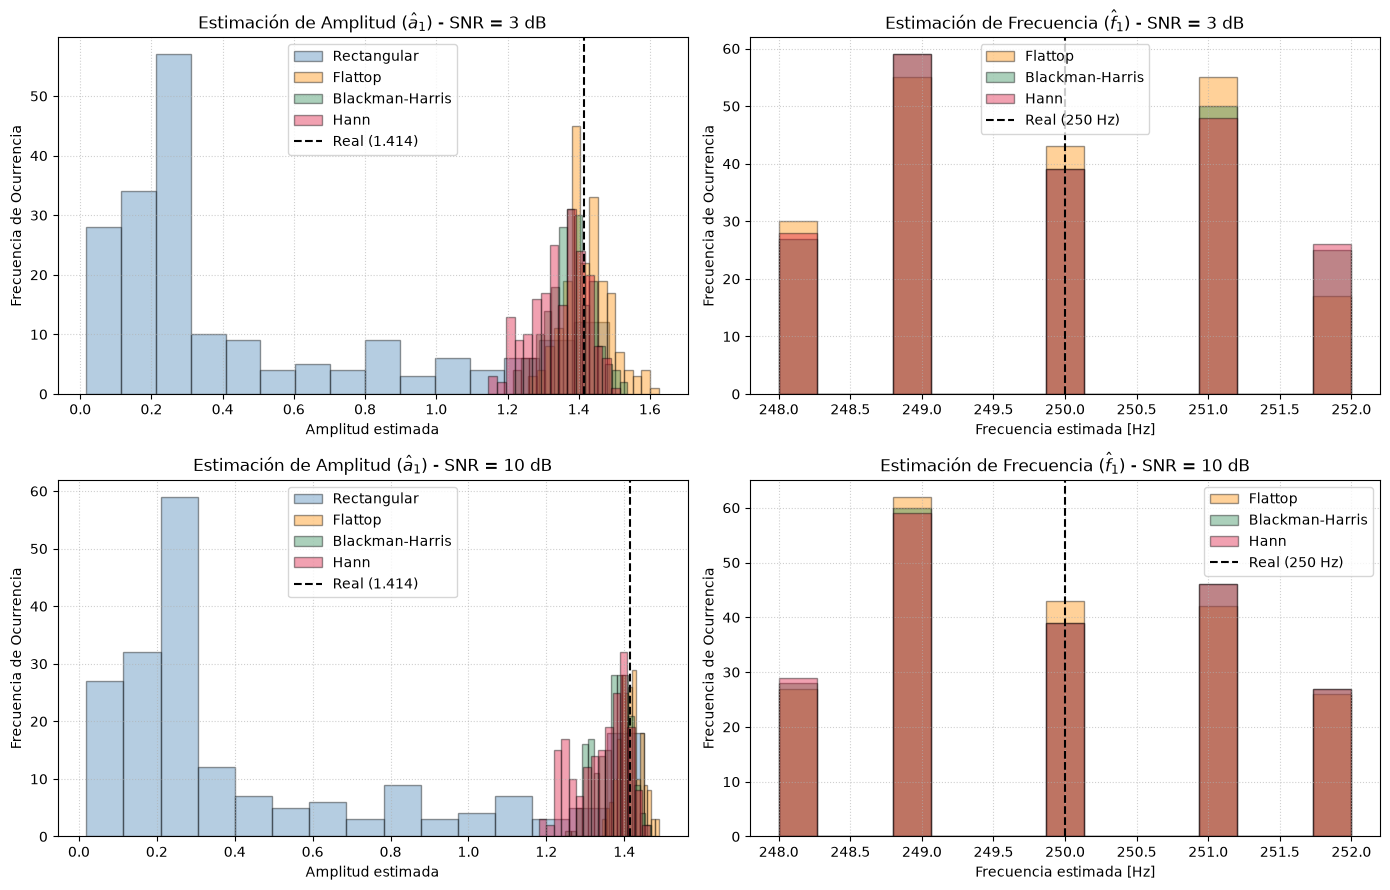

In [10]:
# -----------------------------------------------------------------------------
# Consigna 1: Visualización de Histogramas Comparativos (Sin Warnings)
# -----------------------------------------------------------------------------
snrs = [3, 10]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

colores = {
    'Rectangular': 'steelblue',
    'Flattop': 'darkorange',
    'Blackman-Harris': 'seagreen',
    'Hann': 'crimson'
}

for i, snr_val in enumerate(snrs):
    # --- Histograma de Amplitud ---
    ax_a = axes[i, 0]
    for win_name in resultados[snr_val]:
        a1_data = resultados[snr_val][win_name]['a1']
        ax_a.hist(a1_data, bins=15, alpha=0.4, label=win_name, color=colores[win_name], edgecolor='black')
    
    ax_a.axvline(a0, color='black', linestyle='--', linewidth=1.5, label=f'Real ({a0:.3f})')
    ax_a.set_title(rf'Estimación de Amplitud ($\hat{{a}}_1$) - SNR = {snr_val} dB')
    ax_a.set_xlabel('Amplitud estimada')
    ax_a.set_ylabel('Frecuencia de Ocurrencia')
    ax_a.legend()
    ax_a.grid(True, linestyle=':', alpha=0.6)

    # --- Histograma de Frecuencia ---
    ax_f = axes[i, 1]
    for win_name in resultados[snr_val]:
        if win_name != 'Rectangular': # Excluimos Rectangular fija en 250 Hz para no distorsionar la escala
            f1_data = resultados[snr_val][win_name]['f1']
            ax_f.hist(f1_data, bins=15, alpha=0.4, label=win_name, color=colores[win_name], edgecolor='black')
            
    ax_f.axvline(f0, color='black', linestyle='--', linewidth=1.5, label=f'Real ({f0:.0f} Hz)')
    ax_f.set_title(rf'Estimación de Frecuencia ($\hat{{f}}_1$) - SNR = {snr_val} dB')
    ax_f.set_xlabel('Frecuencia estimada [Hz]')
    ax_f.set_ylabel('Frecuencia de Ocurrencia')
    ax_f.legend()
    ax_f.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [9]:
# -----------------------------------------------------------------------------
# Consigna 2: Tablas de Sesgo y Varianza por SNR (Sin Pandas)
# -----------------------------------------------------------------------------
for snr_val in [3, 10]:
    print(f"\n==================================================================")
    print(f"                      TABLAS PARA SNR = {snr_val} dB")
    print(f"==================================================================")
    
    # --- Tabla de Amplitud ---
    print("\n--- Estimación de Amplitud (a1) ---")
    print(f"{'Ventana':<18} | {'s_a (Sesgo)':<15} | {'v_a (Varianza)':<15}")
    print("-" * 54)
    for win_name in resultados[snr_val]:
        a1_data = resultados[snr_val][win_name]['a1']
        s_a = np.mean(a1_data) - a0
        v_a = np.var(a1_data)
        print(f"{win_name:<18} | {s_a:<15.6f} | {v_a:<15.6f}")

    # --- Tabla de Frecuencia ---
    print("\n--- Estimación de Frecuencia (f1) ---")
    print(f"{'Ventana':<18} | {'s_f [Hz]':<15} | {'v_f [Hz²]':<15}")
    print("-" * 54)
    for win_name in resultados[snr_val]:
        if win_name == 'Rectangular':
            s_f, v_f = 0.0, 0.0
        else:
            f1_data = resultados[snr_val][win_name]['f1']
            s_f = np.mean(f1_data) - f0
            v_f = np.var(f1_data)
        print(f"{win_name:<18} | {s_f:<15.6f} | {v_f:<15.6f}")


                      TABLAS PARA SNR = 3 dB

--- Estimación de Amplitud (a1) ---
Ventana            | s_a (Sesgo)     | v_a (Varianza) 
------------------------------------------------------
Rectangular        | -0.933639       | 0.189545       
Flattop            | 0.006560        | 0.004172       
Blackman-Harris    | -0.041036       | 0.003809       
Hann               | -0.071179       | 0.005908       

--- Estimación de Frecuencia (f1) ---
Ventana            | s_f [Hz]        | v_f [Hz²]      
------------------------------------------------------
Rectangular        | 0.000000        | 0.000000       
Flattop            | -0.130000       | 1.473100       
Blackman-Harris    | -0.065000       | 1.580775       
Hann               | -0.075000       | 1.609375       

                      TABLAS PARA SNR = 10 dB

--- Estimación de Amplitud (a1) ---
Ventana            | s_a (Sesgo)     | v_a (Varianza) 
------------------------------------------------------
Rectangular        | -0.

## Análisis Cualitativo y Conclusiones

### 1. Estimación de Amplitud ($\hat{a}_1$)
* **Ventana Rectangular:** Presenta el sesgo negativo más severo ($\approx -0.93$) debido al fenómeno de *scalloping loss*. Al evaluar únicamente en el bin 250 ($N/4$) y existir desintonía aleatoria ($f_r \neq 0$), la lectura cae fuertemente fuera del pico del lóbulo principal.
* **Ventana Flattop:** Es por lejos la más precisa para amplitud, logrando un sesgo prácticamente nulo ($\approx 0.000$ a $0.006$). Esto confirma su diseño de lóbulo plano, optimizado para medir la magnitud exacta de componentes espectrales sin importar la desintonía.
* **Blackman-Harris y Hann:** Presentan un comportamiento intermedio. Aunque reducen drásticamente el sesgo respecto a la rectangular, conservan un sesgo negativo ligero ($\approx -0.04$ y $-0.07$ respectivamente) dado que sus lóbulos principales decrecen más rápido hacia los bordes del bin.

### 2. Estimación de Frecuencia ($\hat{f}_1$)
* Al utilizar la resolución espectral nativa ($\Delta f = 1 \text{ Hz}$) mediante la búsqueda del bin máximo ($\text{argmax}$), las tres ventanas principales (Flattop, Blackman-Harris y Hann) muestran un desempeño muy similar, con un sesgo de frecuencia acotado ($\approx -0.06$ a $-0.13 \text{ Hz}$) y una varianza cercana a la teórica para la distribución de la desintonía ($\text{Var}(f_r) \approx 1.33 \text{ Hz}^2$).

### 3. Impacto de la SNR ($3 \text{ dB}$ vs. $10 \text{ dB}$)
* **Sesgo ($s_a, s_f$):** Se mantiene casi invariante ante el aumento de potencia de la señal respecto al ruido. Esto demuestra que el sesgo es una propiedad estructural dependiente del enventanado y la desintonía, no del nivel de ruido AWGN.
* **Varianza ($v_a, v_f$):** Al pasar de $3 \text{ dB}$ a $10 \text{ dB}$, la varianza de la estimación de amplitud disminuye sensiblemente en todas las ventanas (por ejemplo, cae de $0.0041$ a $0.0008$ en la Flattop), lo que se traduce en distribuciones mucho más estrechas y concentradas en los histogramas.